## Duplicates in data?

We noticed some oddities in the plots when evaluating the models, that might come as a result of duplicates in the data...

Split (seed=42): train=7136 (4250 cls), val=1102 (405 new_whale), test=1612 (405 new_whale)
Hashing …
  9850 images kept.
  735 exact-duplicate pairs.



,bucket,pairs,images_affected,pool (known-test),pool (known-train),pool (known-val),pool (new-test),pool (new-val)
0,known-train × known-train,234,468,NaN,7136.0,NaN,NaN,NaN
1,known-test × known-train,190,380,1207.0,7136.0,NaN,NaN,NaN
2,known-train × known-val,121,242,NaN,7136.0,697.0,NaN,NaN
3,known-train × new-test,68,136,NaN,7136.0,NaN,405.0,NaN
4,known-train × new-val,62,123,NaN,7136.0,NaN,NaN,405.0
5,known-test × known-val,22,44,1207.0,NaN,697.0,NaN,NaN
6,known-test × new-val,12,24,1207.0,NaN,NaN,NaN,405.0
7,known-val × new-val,11,22,NaN,NaN,697.0,NaN,405.0
8,known-test × new-test,8,16,1207.0,NaN,NaN,405.0,NaN
9,known-val × new-test,6,12,NaN,NaN,697.0,405.0,NaN



[known-test  ×  known-train]  190 pairs · 380 affected (pool: known-test=1207, known-train=7136)


,image_a,id_a,split_a,image_b,id_b,split_b
0,6b7e611f.jpg,w_44cccf6,test,ab23c714.jpg,w_44cccf6,train
1,50ada087.jpg,w_d9055d1,train,9dc8cf7f.jpg,w_d9055d1,test


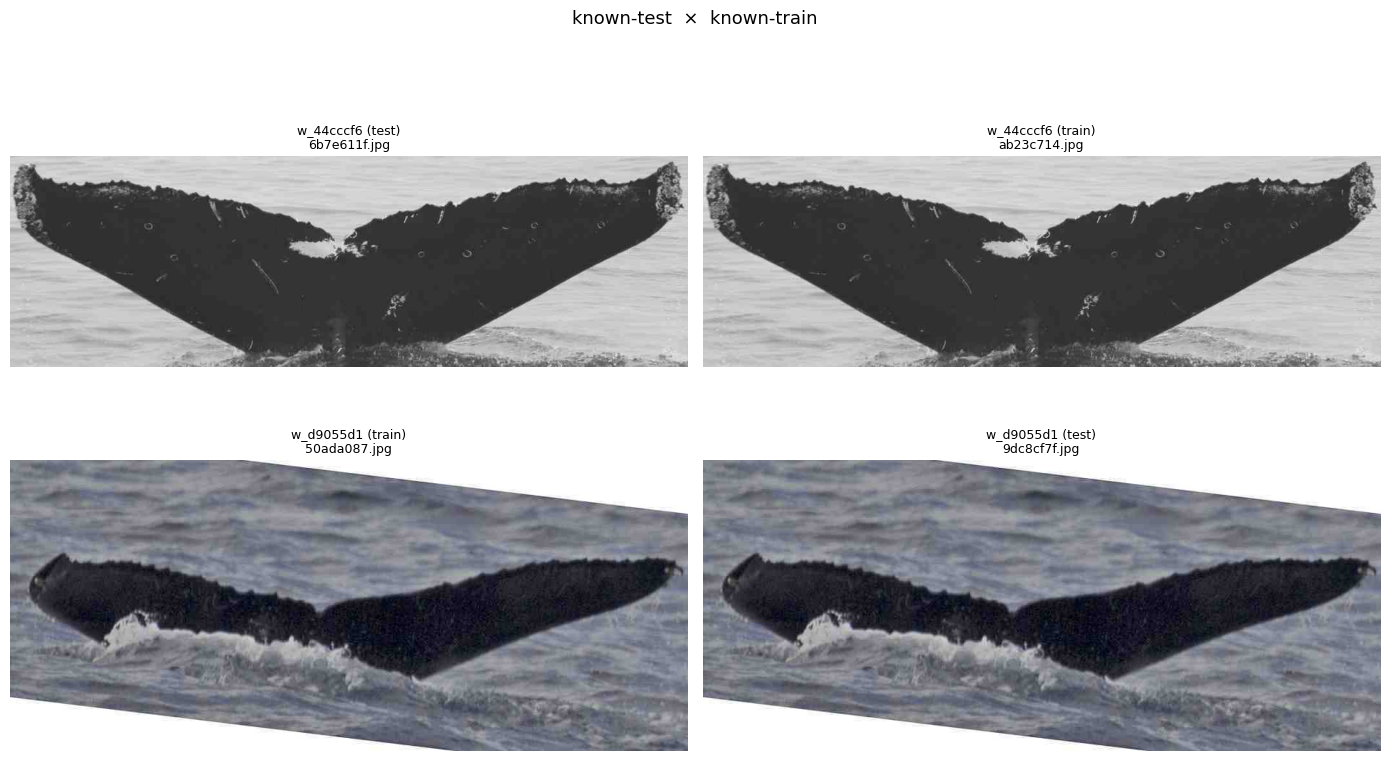


[known-test  ×  known-val]  22 pairs · 44 affected (pool: known-test=1207, known-val=697)


,image_a,id_a,split_a,image_b,id_b,split_b
0,c29996d3.jpg,w_ea2385d,test,cf91da02.jpg,w_ea2385d,val
1,0101d22b.jpg,w_af67683,val,7f19b200.jpg,w_af67683,test


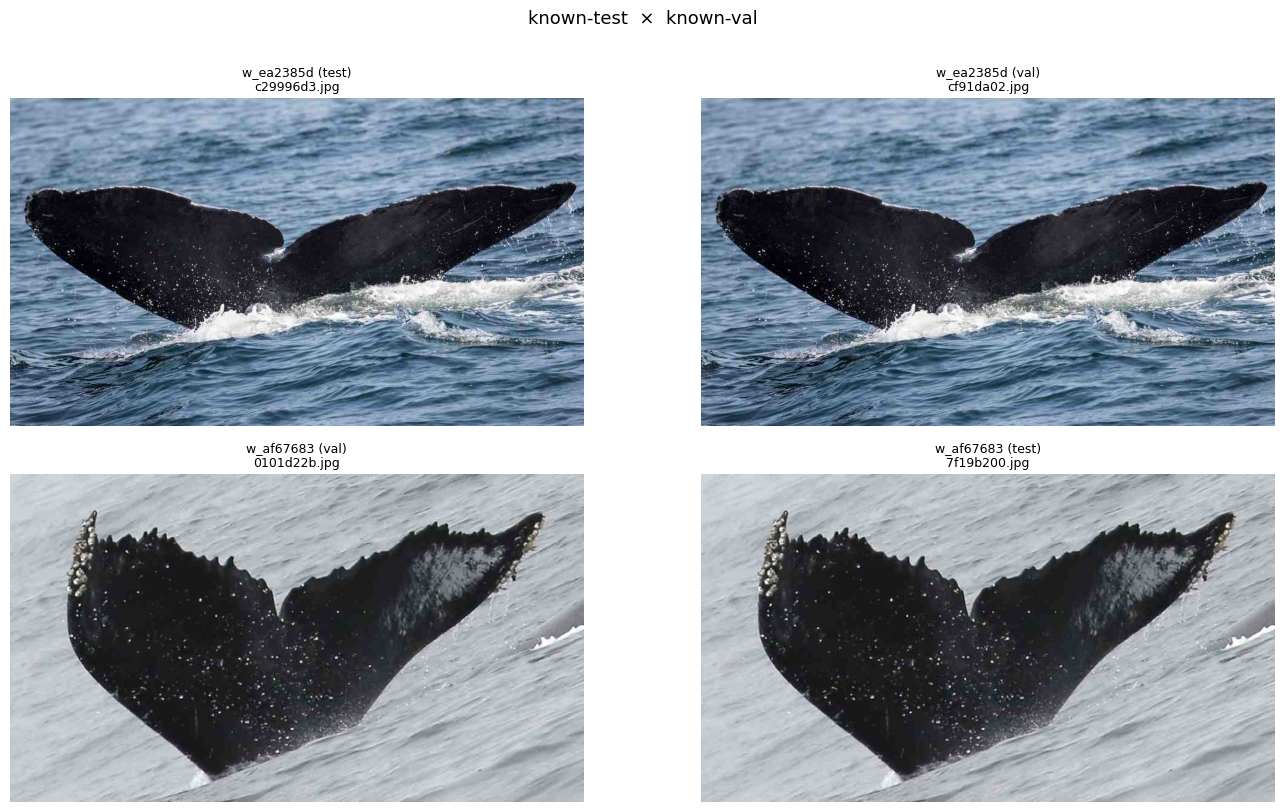


[known-test  ×  new-test]  8 pairs · 16 affected (pool: known-test=1207, new-test=405)


,image_a,id_a,split_a,image_b,id_b,split_b
0,2f778f6c.jpg,new_whale,test,bb2a1714.jpg,w_3de676c,test
1,3e91ad0d.jpg,w_8a4b8ef,test,f7b4598a.jpg,new_whale,test


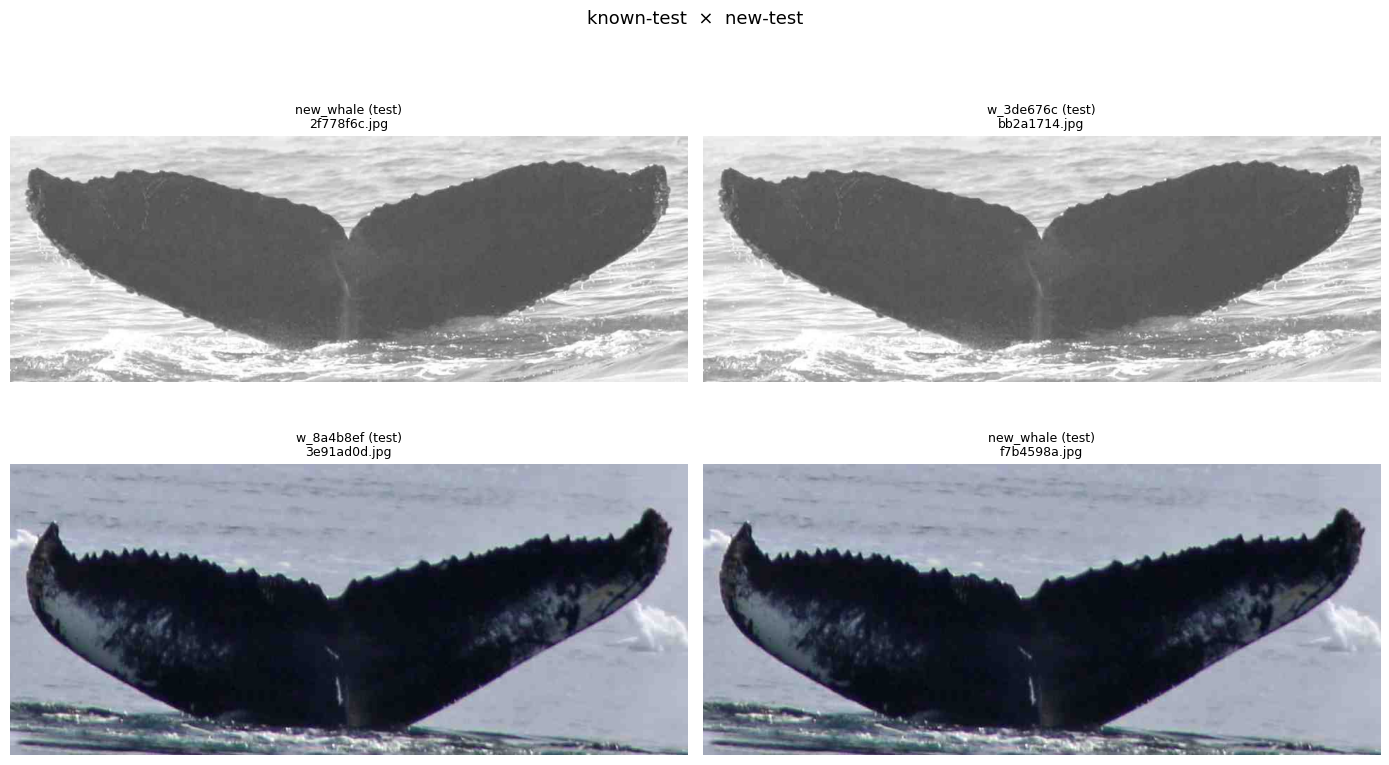


[known-test  ×  new-val]  12 pairs · 24 affected (pool: known-test=1207, new-val=405)


,image_a,id_a,split_a,image_b,id_b,split_b
0,8e6cd7f4.jpg,new_whale,val,caa04386.jpg,w_97bc172,test
1,2c9bbea5.jpg,w_c0560ac,test,f3c1b087.jpg,new_whale,val


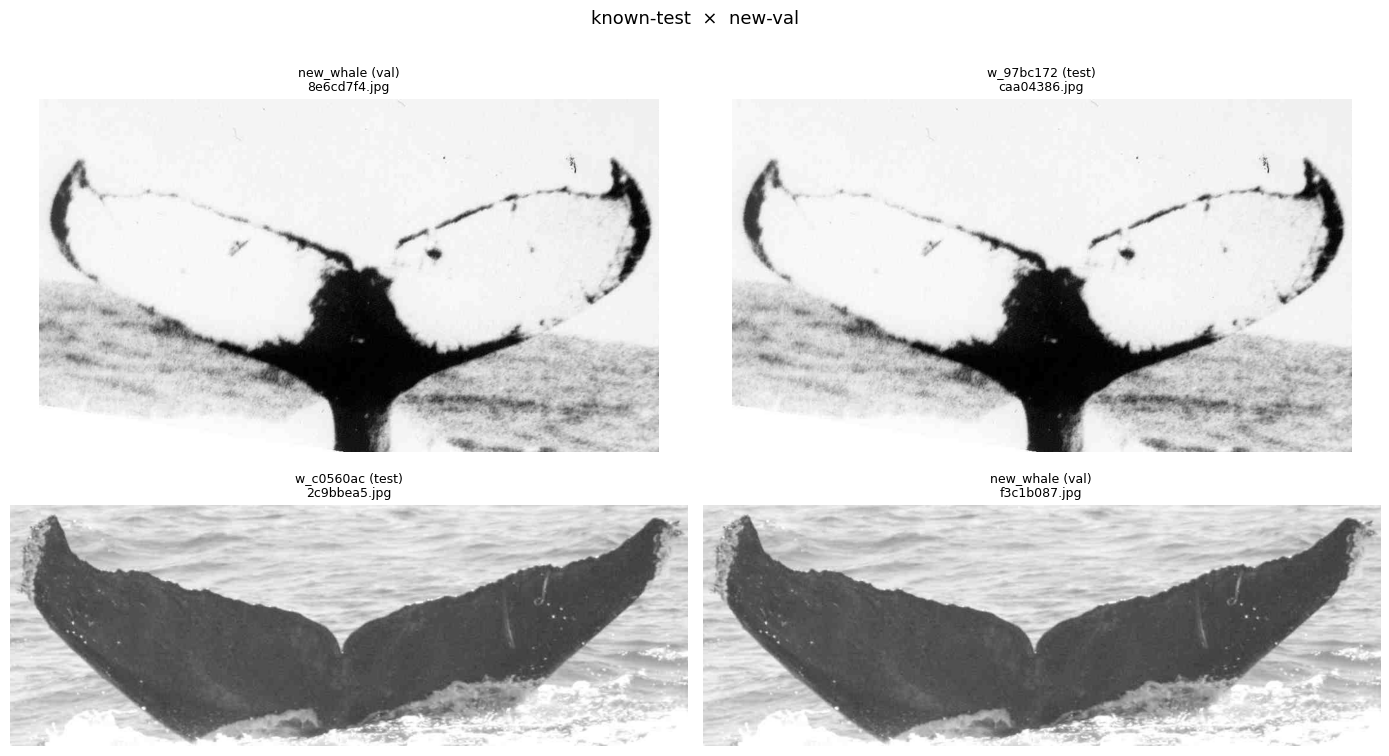


[known-train  ×  known-train]  234 pairs · 468 affected (pool: known-train=7136, known-train=7136)


,image_a,id_a,split_a,image_b,id_b,split_b
0,0c35fcb4.jpg,w_7028d77,train,2d6610b9.jpg,w_f6bca7a,train
1,0344cc34.jpg,w_fea7fe6,train,2af4d9b7.jpg,w_fea7fe6,train


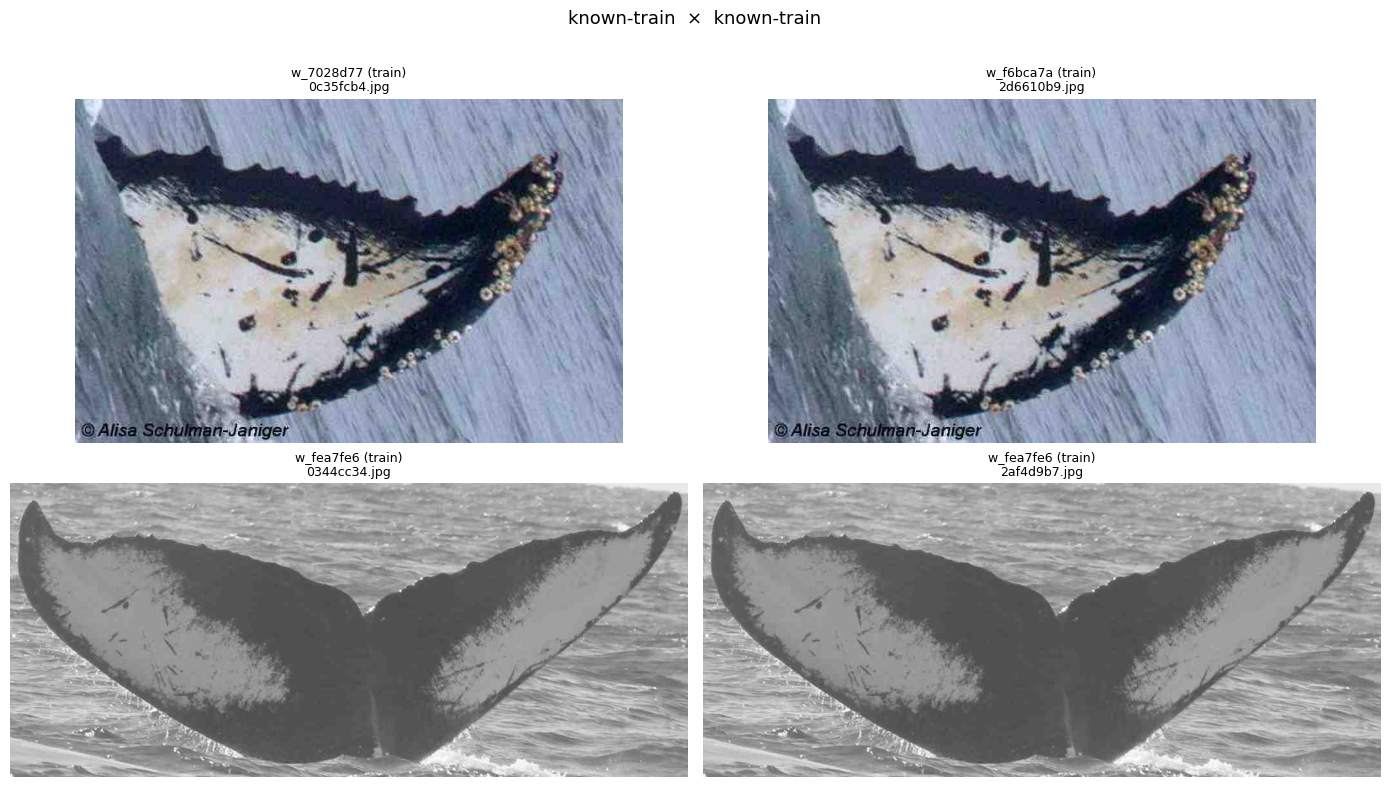


[known-train  ×  known-val]  121 pairs · 242 affected (pool: known-train=7136, known-val=697)


,image_a,id_a,split_a,image_b,id_b,split_b
0,513b0516.jpg,w_febafc1,train,a325fa59.jpg,w_febafc1,val
1,177c6621.jpg,w_7a2dfd7,train,f820e4e2.jpg,w_7a2dfd7,val


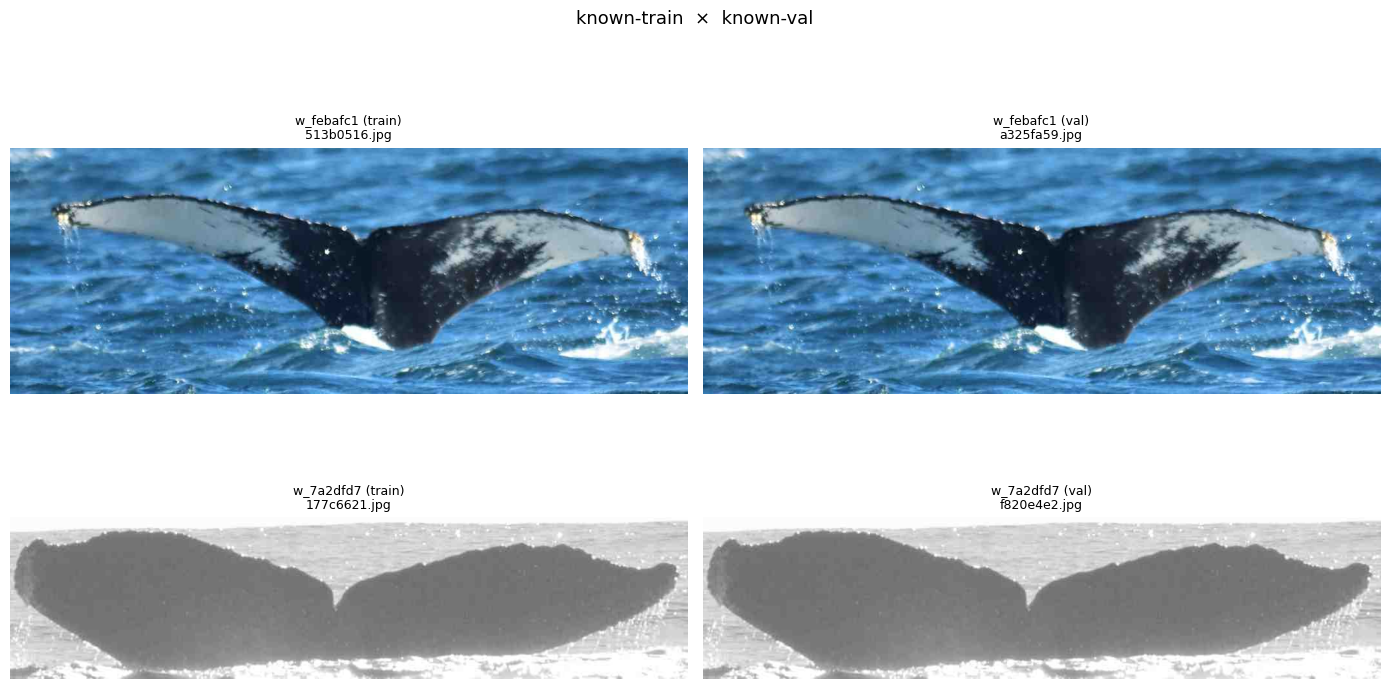


[known-train  ×  new-test]  68 pairs · 136 affected (pool: known-train=7136, new-test=405)


,image_a,id_a,split_a,image_b,id_b,split_b
0,ab988b3e.jpg,new_whale,test,b23d1ca7.jpg,w_d62128e,train
1,2b3fd959.jpg,new_whale,test,7b12411a.jpg,w_2739d94,train


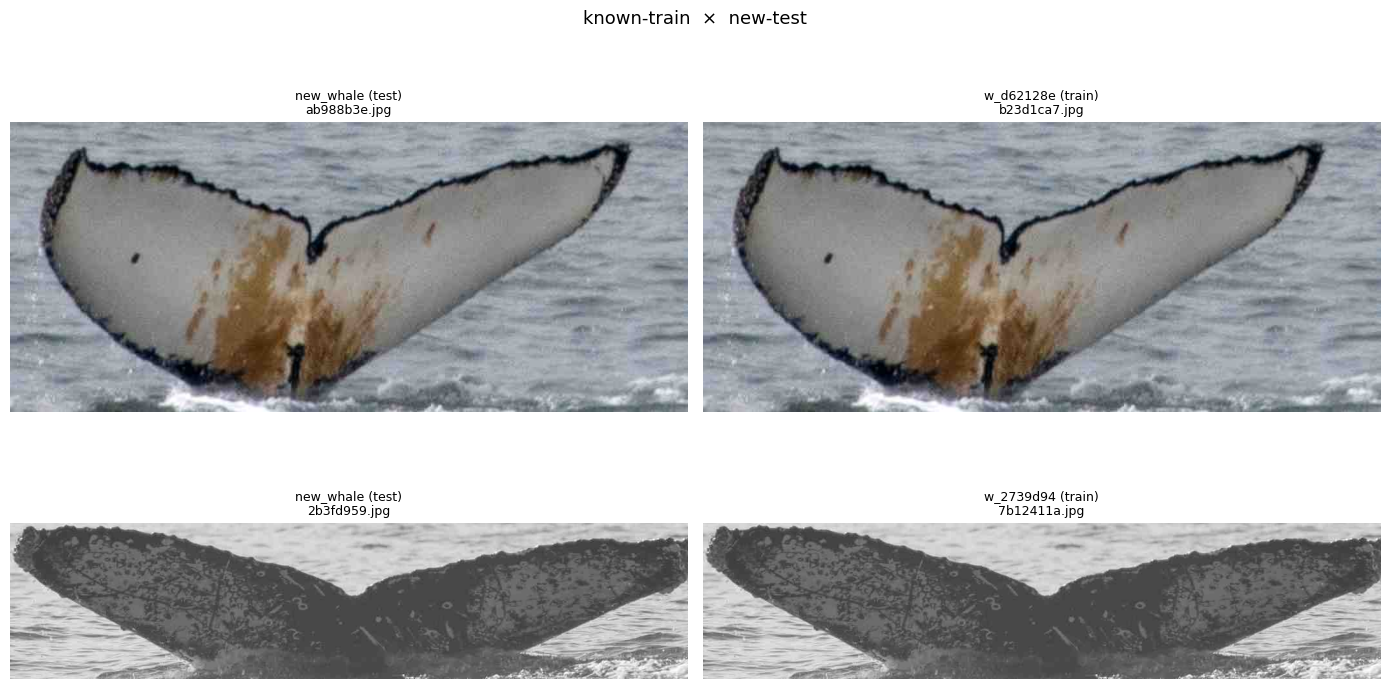


[known-train  ×  new-val]  62 pairs · 123 affected (pool: known-train=7136, new-val=405)


,image_a,id_a,split_a,image_b,id_b,split_b
0,4398e933.jpg,w_c666071,train,fa2b1d93.jpg,new_whale,val
1,0ca843f9.jpg,w_5a0d250,train,b5573551.jpg,new_whale,val


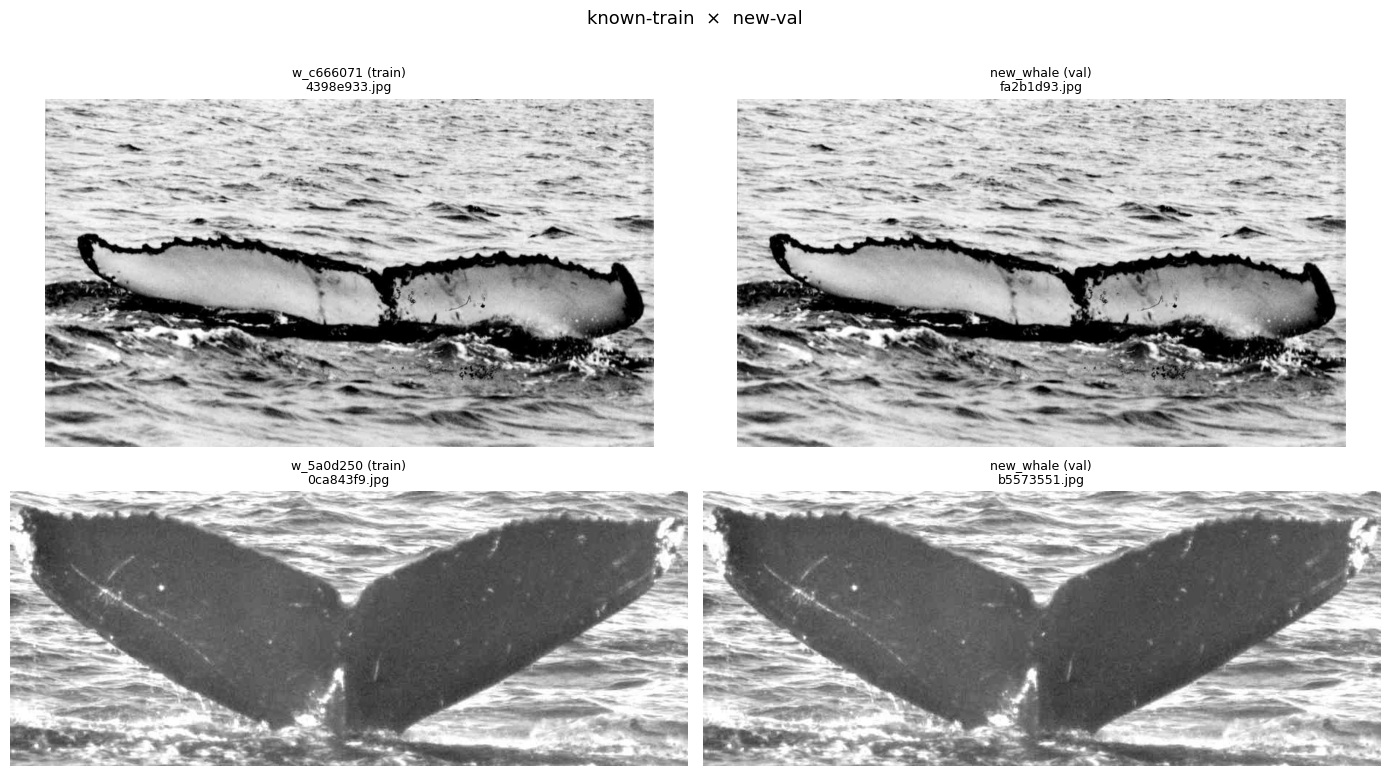


[known-val  ×  new-test]  6 pairs · 12 affected (pool: known-val=697, new-test=405)


,image_a,id_a,split_a,image_b,id_b,split_b
0,219b9d5b.jpg,new_whale,test,c7996a54.jpg,w_7028d77,val
1,01cf2e2e.jpg,new_whale,test,01dd608b.jpg,w_12c3d3d,val


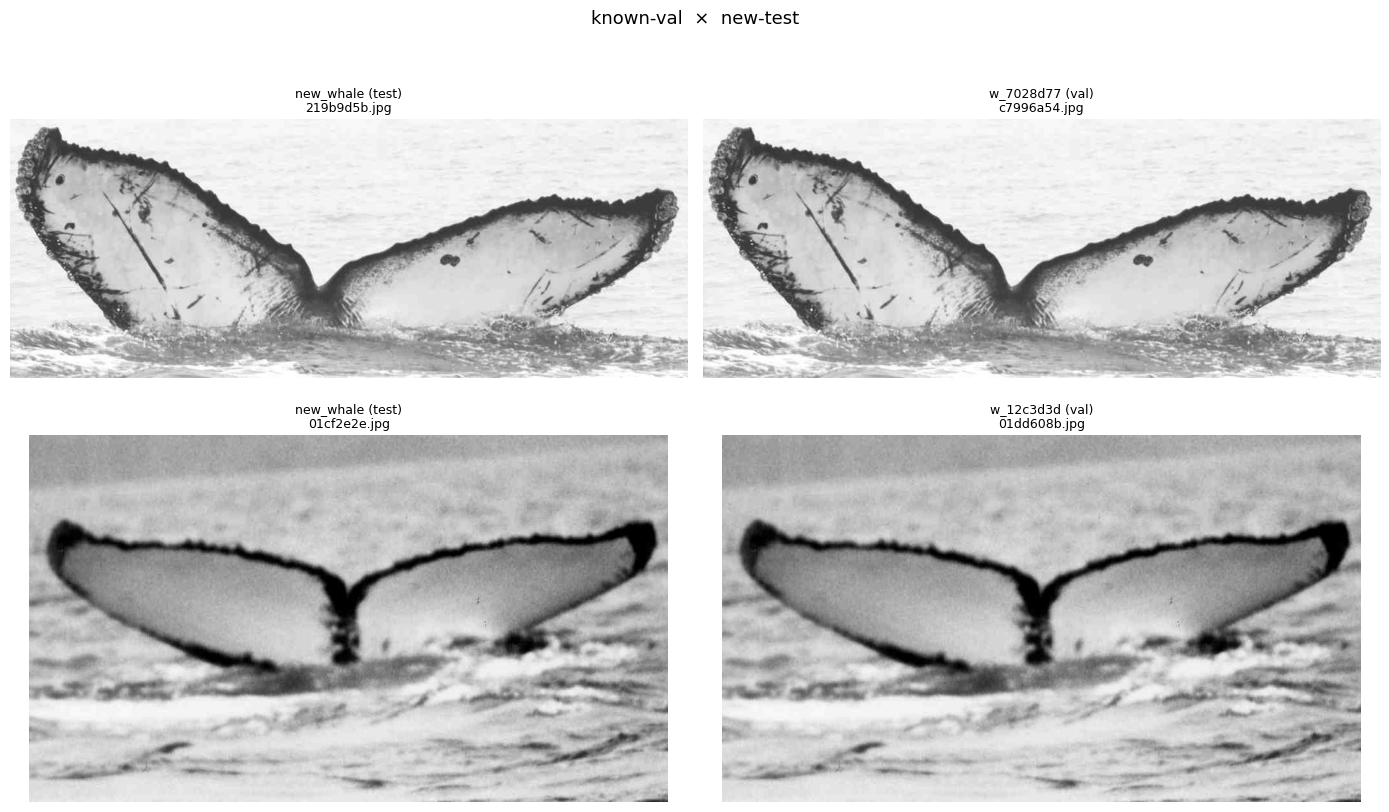


[known-val  ×  new-val]  11 pairs · 22 affected (pool: known-val=697, new-val=405)


,image_a,id_a,split_a,image_b,id_b,split_b
0,508958a1.jpg,new_whale,val,adce1628.jpg,w_22bb9b3,val
1,64566f1b.jpg,new_whale,val,a9767dd2.jpg,w_95874a5,val


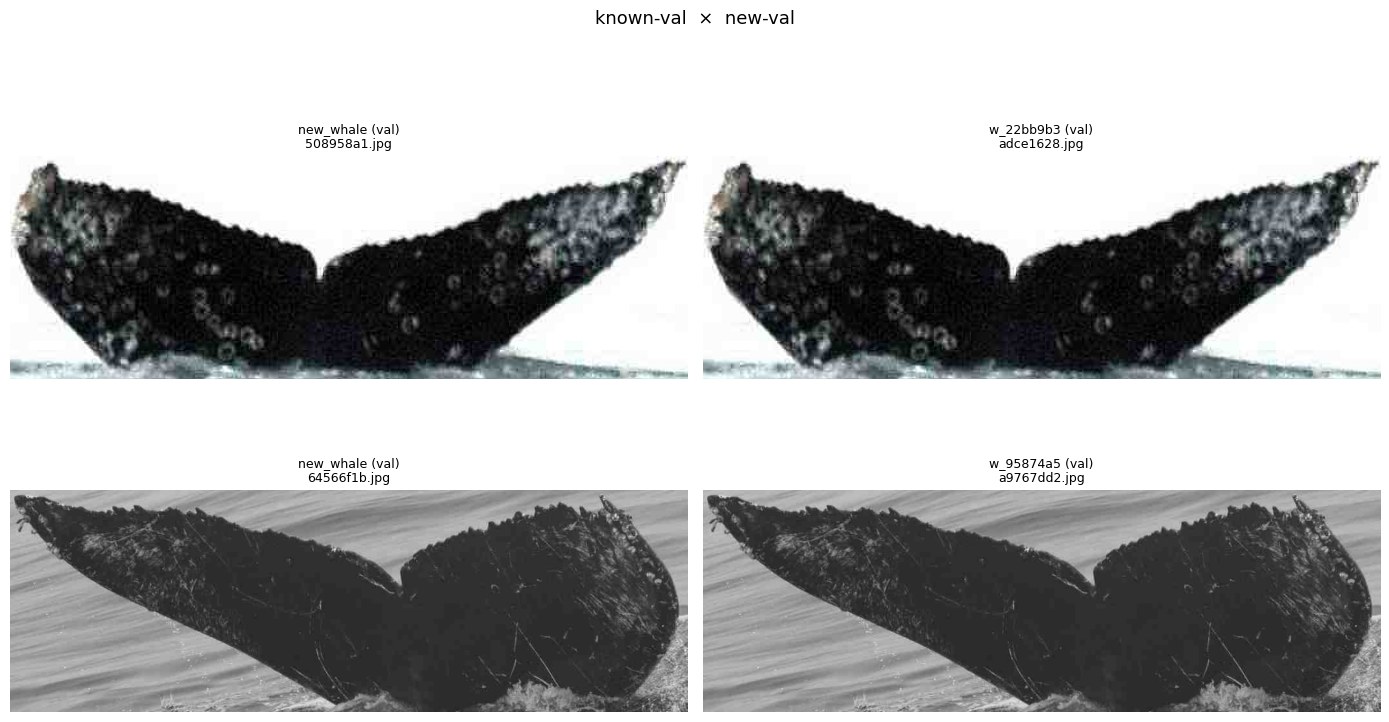


[new-test  ×  new-val]  1 pairs · 2 affected (pool: new-test=405, new-val=405)


,image_a,id_a,split_a,image_b,id_b,split_b
0,b373ccf9.jpg,new_whale,test,d3050057.jpg,new_whale,val


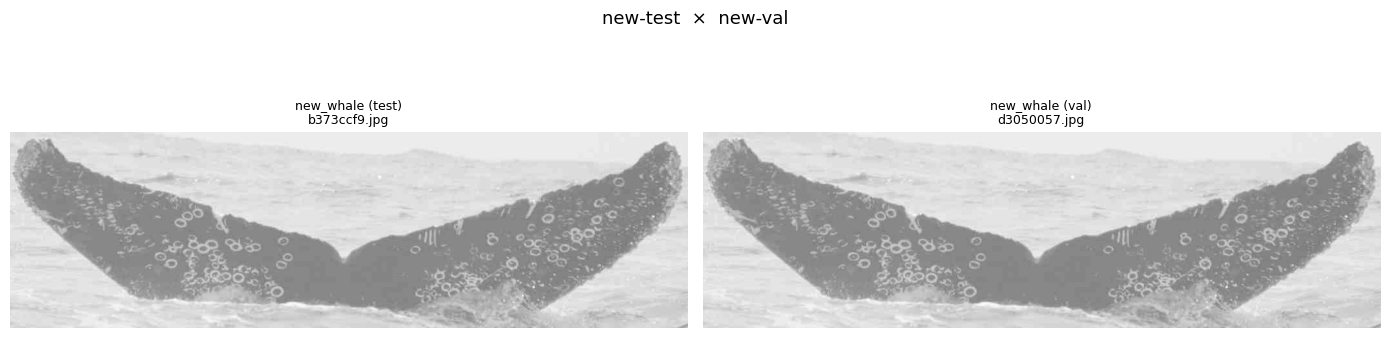


Done.


In [1]:
# --- Exact duplicate audit: split-aware cross-tab + spot-check samples ---
# Requires: `data` dict from prepare_data already in scope, images under data/train/

import hashlib
import itertools
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

from config import ExperimentConfig
from dataset import prepare_data

IMAGE_ROOT = Path("data") / "train"

config = ExperimentConfig(
    experiment_name="test_prepare_data",
    description="Just testing preparing data")

data = prepare_data(config)

# ── 1. Fingerprint ───────────────────────────────────────────────────────

fp_df = pd.read_csv(Path("data") / "train.csv")[["Image", "Id"]].copy()
fp_df["path"] = fp_df["Image"].map(lambda n: IMAGE_ROOT / n)
fp_df = fp_df[fp_df["path"].map(Path.exists)].reset_index(drop=True)


def _sha1(p):
    h = hashlib.sha1()
    with open(p, "rb") as f:
        for blk in iter(lambda: f.read(1 << 20), b""):
            h.update(blk)
    return h.hexdigest()


print("Hashing …")
fp_df["sha1"] = fp_df["path"].map(_sha1)

# ── 2. Split tags from existing `data` (no re-calling prepare_data) ──────

split_map = {img: "train" for img in data["train_df"]["Image"]}
split_map.update({img: "val" for img in data["val_df"]["Image"]})
split_map.update({img: "test" for img in data["test_df"]["Image"]})

fp_df["split"] = fp_df["Image"].map(split_map)
n_dropped = fp_df["split"].isna().sum()
if n_dropped:
    print(f"  {n_dropped} images not in any split (new_whale/rare dropped from train) — excluded.")
fp_df = fp_df.dropna(subset=["split"]).reset_index(drop=True)
fp_df["family"] = np.where(fp_df["Id"] == "new_whale", "new", "known")
fp_df["side"] = fp_df["family"] + "-" + fp_df["split"]
print(f"  {len(fp_df)} images kept.")

pool = fp_df["side"].value_counts().to_dict()

# ── 3. Exact-duplicate pairs ─────────────────────────────────────────────

pair_rows = []
for _, grp in fp_df.groupby("sha1"):
    if len(grp) < 2:
        continue
    for ia, ib in itertools.combinations(grp.index, 2):
        a, b = fp_df.loc[ia], fp_df.loc[ib]
        sa, sb = a["side"], b["side"]
        side1, side2 = sorted([sa, sb])
        pair_rows.append({
            "image_a": a["Image"], "id_a": a["Id"],
            "split_a": a["split"], "family_a": a["family"], "side_a": sa,
            "image_b": b["Image"], "id_b": b["Id"],
            "split_b": b["split"], "family_b": b["family"], "side_b": sb,
            "side_1": side1, "side_2": side2,
            "bucket": f"{side1}  ×  {side2}",
        })

pairs = pd.DataFrame(pair_rows)
print(f"  {len(pairs)} exact-duplicate pairs.\n")


# ── 4. Cross-tab ─────────────────────────────────────────────────────────

def _affected(sub):
    return set(sub["image_a"]) | set(sub["image_b"])


if len(pairs):
    rows = []
    for bucket, g in pairs.groupby("bucket"):
        s1, s2 = g.iloc[0]["side_1"], g.iloc[0]["side_2"]
        n_aff = len(_affected(g))
        rows.append({
            "bucket": bucket,
            "pairs": len(g),
            "images_affected": n_aff,
            f"pool ({s1})": pool.get(s1, 0),
            f"pool ({s2})": pool.get(s2, 0),
        })
    ct = pd.DataFrame(rows).sort_values("pairs", ascending=False).reset_index(drop=True)
    display(ct)
else:
    print("No exact-duplicate pairs found.")

# ── 5. Spot-check (≤2 samples per bucket) ────────────────────────────────

resample = getattr(Image, "Resampling", Image).BILINEAR

buckets_to_show = sorted(pairs["bucket"].unique()) if len(pairs) else []

for bucket in buckets_to_show:
    sub = pairs[pairs["bucket"] == bucket]
    aff = _affected(sub)
    s1, s2 = sub.iloc[0]["side_1"], sub.iloc[0]["side_2"]

    n = min(2, len(sub))
    samp = sub.sample(n=n, random_state=42).reset_index(drop=True)

    print(f"\n[{bucket}]  {len(sub)} pairs · {len(aff)} affected "
          f"(pool: {s1}={pool.get(s1,0)}, {s2}={pool.get(s2,0)})")
    display(samp[["image_a", "id_a", "split_a", "image_b", "id_b", "split_b"]])

    fig, axes = plt.subplots(n, 2, figsize=(14, 4 * n), squeeze=False)
    for i, r in samp.iterrows():
        a = Image.open(IMAGE_ROOT / r["image_a"]).convert("RGB")
        b = Image.open(IMAGE_ROOT / r["image_b"]).convert("RGB")
        w, h = min(a.width, b.width), min(a.height, b.height)
        ar, br = a.resize((w, h), resample), b.resize((w, h), resample)

        axes[i, 0].imshow(a); axes[i, 0].axis("off")
        axes[i, 0].set_title(f"{r['id_a']} ({r['split_a']})\n{r['image_a']}", fontsize=9)
        axes[i, 1].imshow(b); axes[i, 1].axis("off")
        axes[i, 1].set_title(f"{r['id_b']} ({r['split_b']})\n{r['image_b']}", fontsize=9)

    plt.suptitle(bucket, fontsize=13, y=1.01)
    plt.tight_layout(); plt.show()

print("\nDone.")

**Conclusion:** Alot of images in test have exact duplicates in training data, meaning the baseline isnt doing as well as we thought it was, however, we have also done some tests and seen that some copies have different labels, which again hurt performance, so it evens out